In [17]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

In [18]:
train_dir = "./train"
test_dir = "./test"

# Obtener nombres de clases y mapearlas a índices
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

def load_dataset(folder):
    X, y = [], []
    for label in os.listdir(folder):
        class_dir = os.path.join(folder, label)
        if os.path.isdir(class_dir):
            for file in os.listdir(class_dir):
                img_path = os.path.join(class_dir, file)
                img = Image.open(img_path).resize((28,28))
                X.append(np.array(img, dtype=np.float32) / 255.0)  # normalización 0-1
                y.append(class_to_idx[label])
    return np.array(X), np.array(y)

X_train, y_train = load_dataset(train_dir)
X_test, y_test = load_dataset(test_dir)

# Aplanar imágenes
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("Train:", X_train_flat.shape, y_train.shape)
print("Test:", X_test_flat.shape, y_test.shape)

Train: (28709, 784) (28709,)
Test: (7178, 784) (7178,)


In [19]:
y_train_happy = (y_train == class_to_idx["happy"]).astype(int)
y_test_happy = (y_test == class_to_idx["happy"]).astype(int)

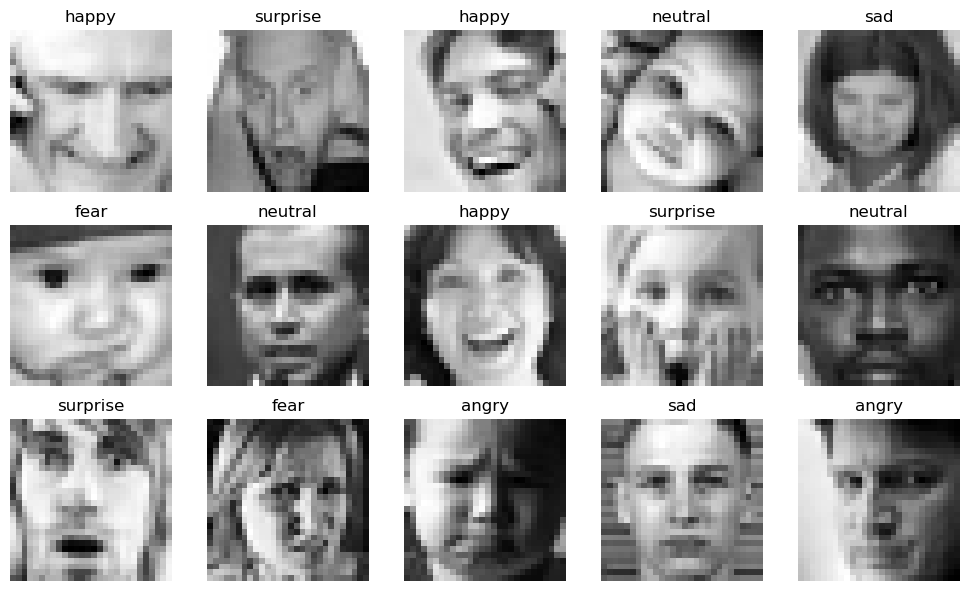

In [20]:
r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))
for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)
        ix = random.randint(0, len(X_train)-1)
        img = X_train[ix]
        plt.imshow(img.reshape(28,28), cmap='gray')
        plt.axis("off")
        plt.title(class_names[y_train[ix]])
plt.tight_layout()
plt.show()

In [21]:
def bce(y, y_hat):
    return - np.mean(y*np.log(y_hat) - (1 - y)*np.log(1 - y_hat))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class Perceptron():
    def __init__(self, size):
        self.w = np.random.normal(loc=0.0, scale=np.sqrt(2/(size+1)), size=(size,))
        self.ws = []
        self.activation = sigmoid
        self.loss = bce
    
    def __call__(self, w, x):
        return self.activation(np.dot(x, w))
    
    def fit(self, x, y, epochs, lr, verbose=True):
        x = np.c_[np.ones(len(x)), x]  # agregar columna de 1 para bias
        for epoch in range(1, epochs+1):
            y_hat = self(self.w, x)
            l = self.loss(y, y_hat)
            dldh = y_hat - y
            dhdw = x
            dldw = np.dot(dldh, dhdw)
            self.w = self.w - lr*dldw
            self.ws.append(self.w.copy())
            if verbose:
                print(f"Epoch {epoch}/{epochs} Loss {l}")

In [22]:
np.random.seed(42)
perceptron = Perceptron(X_train_flat.shape[1] + 1)
epochs, lr = 1000, 1e-6
perceptron.fit(X_train_flat, y_train_happy, epochs, lr)

Epoch 1/1000 Loss -0.23841574576285648
Epoch 2/1000 Loss 0.21809571720843107
Epoch 3/1000 Loss 0.107683493735274
Epoch 4/1000 Loss 0.11139703623563621
Epoch 5/1000 Loss 0.11051276277076814
Epoch 6/1000 Loss 0.11022877230649433
Epoch 7/1000 Loss 0.10988206404763277
Epoch 8/1000 Loss 0.10955527210987424
Epoch 9/1000 Loss 0.10923750307216627
Epoch 10/1000 Loss 0.1089296509643744
Epoch 11/1000 Loss 0.10863114706800968
Epoch 12/1000 Loss 0.10834162673821826
Epoch 13/1000 Loss 0.10806071871788078
Epoch 14/1000 Loss 0.10778807090009086
Epoch 15/1000 Loss 0.10752334632538575
Epoch 16/1000 Loss 0.1072662229509803
Epoch 17/1000 Loss 0.1070163929668232
Epoch 18/1000 Loss 0.10677356219143459
Epoch 19/1000 Loss 0.10653744948065255
Epoch 20/1000 Loss 0.10630778615786098
Epoch 21/1000 Loss 0.10608431546460766
Epoch 22/1000 Loss 0.10586679203163739
Epoch 23/1000 Loss 0.10565498137010038
Epoch 24/1000 Loss 0.10544865938265577
Epoch 25/1000 Loss 0.10524761189411634
Epoch 26/1000 Loss 0.10505163420122464

In [23]:
def evaluate(perceptron, x, t=0.4):
    w = perceptron.ws[-1]
    x = np.c_[np.ones(len(x)), x]
    y = perceptron(w, x)
    return (y > t).astype(np.int32)

def accuracy(y_pred, y):
    return np.sum(y_pred == y) / len(y)

In [24]:
y_pred_train = evaluate(perceptron, X_train_flat)
y_pred_test = evaluate(perceptron, X_test_flat)

print("Accuracy train:", accuracy(y_pred_train, y_train_happy))
print("Accuracy test:", accuracy(y_pred_test, y_test_happy))
print("Porcentaje no-happy train / test:", 1 - y_train_happy.mean(), 1 - y_test_happy.mean())


Accuracy train: 0.7532132780661117
Accuracy test: 0.7599609919197549
Porcentaje no-happy train / test: 0.7486850813333799 0.7528559487322374


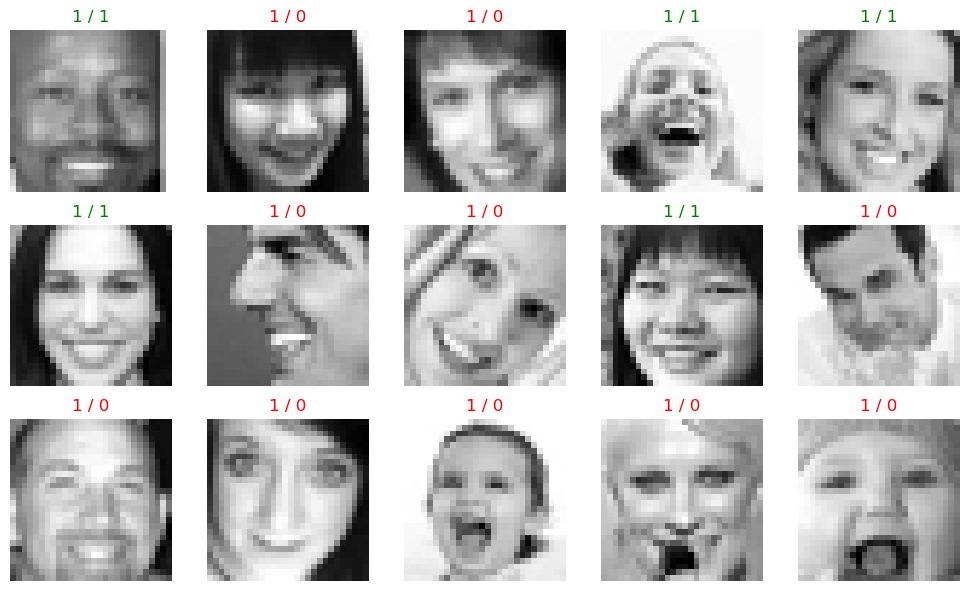

In [25]:
r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))


happy_indices = np.where(y_test_happy == 1)[0]

for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)
        
        ix = random.choice(happy_indices)
        img = X_test[ix]
        plt.imshow(img.reshape(28,28), cmap='gray')
        plt.axis("off")
        y_pred = evaluate(perceptron, [X_test_flat[ix]])
        plt.title(f"{y_test_happy[ix]} / {y_pred[0]}",
                  color="red" if y_test_happy[ix] != y_pred[0] else "green")

plt.tight_layout()
plt.show()


In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test_happy, y_pred_test)

0.7599609919197549

In [28]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_happy, y_pred_test)

array([[4956,  448],
       [1275,  499]])

In [29]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_test_happy, y_pred_test), recall_score(y_test_happy, y_pred_test)

(0.5269271383315733, 0.28128523111612175)

In [30]:
from sklearn.metrics import f1_score

f1_score(y_test_happy, y_pred_test)

0.3667769202499081

In [31]:
def evaluate2(perceptron, x):
    w = perceptron.ws[-1]
    x = np.c_[np.ones(len(x)), x]
    y = perceptron(w, x)
    return y

In [33]:
from sklearn.metrics import roc_curve

y_pred2 = evaluate2(perceptron, X_test_flat)
fpr, tpr, thresholds = roc_curve(y_test_happy, y_pred2)

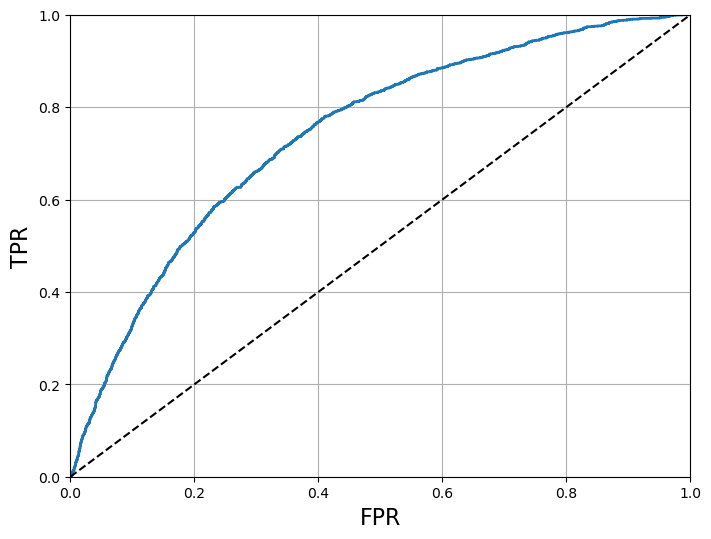

In [35]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.axis([0, 1, 0, 1])                                    
    plt.xlabel('FPR', fontsize=16) 
    plt.ylabel('TPR', fontsize=16)    
    plt.grid(True)                                            

plt.figure(figsize=(8, 6))                         
plot_roc_curve(fpr, tpr)              
plt.show()

In [36]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test_happy, y_pred2)

0.741618019388536